In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import LogLocator, NullFormatter
import struct

import scienceplots
from tqdm import tqdm

plt.style.use(['science','notebook','grid'])
jax.config.update("jax_enable_x64", True)

from scipy.fft import fftn,ifftn,fftshift
from numba import njit, prange, jit
from time import time
import sys,pathlib,os #, concurrent.futures

In [2]:
%%html
<style>
.jp-Notebook {
  --jp-notebook-max-width: 98%;
}</style>

In [3]:
PI = np.pi
TWO_PI = 2*PI
N = 2**9

L = 2*PI

dx = L/N

shells = np.arange(-0.5,N//2+1,1)
shells[0] = 0.

# ---------------- Parameters ----------------
num_samples = 2**22  # total random pairs
p_orders = np.array([1.0, 2.0, 3.0, 4.0 ,5.0 ,6.0], dtype=np.float64)
bins = np.linspace(0, N/2, N//2)  # radial bins

r = np.arange(0,512)*dx



""" If the number of vectors for a given r is more than 100000, we will keep randomly chosen 100000 of them"""
maxrhats = 100000 
maxcenters = 100000
lent = 11


X = Y =Z = np.linspace(0,TWO_PI,N,endpoint=False)
dx = dy = dz = X[1] - X[0]
x,y,z = np.meshgrid(X,Y,Z, indexing='ij')
idxs = np.arange(N)
vec = ((np.array(np.meshgrid(idxs,idxs,idxs,indexing='ij'))).astype(int) - N//2).reshape((3,N**3))
norms = np.linalg.norm(vec,axis=0)


centres = np.random.randint(0,N**3,(maxcenters))
newvecs = np.zeros((3,0))
cond = np.zeros((N**3,),dtype=bool)
cidx = np.zeros((maxrhats,),dtype=int)

norms.shape

(134217728,)

In [4]:
# ---------------- Velocity field ----------------#

u = np.load('/users/anikat/Desktop/Projects/Decimated_Navier_Stokes/Fractal_velocity_field_Real/Decimated_Fractal_D_2p98.npz')['u_real']

s_1 = np.zeros(N)

print("Velocity field:", u.shape)

Velocity field: (3, 512, 512, 512)


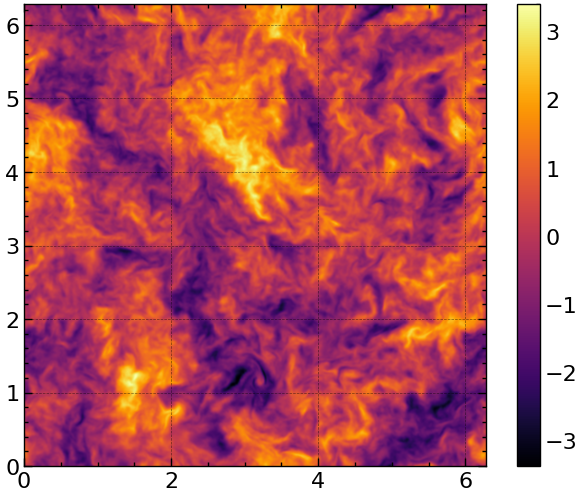

In [5]:
plt.imshow(u[0,290,:,:].T , origin = 'lower', extent = [0,L,0,L], cmap = 'inferno')
plt.colorbar()

In [6]:
for r in range(N//2+1):
    cond[:] = (norms > r - 0.5)*(norms < r + 0.5)
    if cond.sum() > maxrhats:
        idx = np.argwhere(cond).ravel()
        cidx = np.random.choice(idx, maxrhats, replace=False)
        newvecs = np.append(newvecs, vec[:,cidx],axis=1)
    else:
        idx = np.argwhere(cond).ravel()
        newvecs = np.append(newvecs, vec[:,idx],axis=1)

del vec,norms
vec = newvecs
del newvecs
""" Now, we can use this new vecs """
Nvec = vec.shape[1]
norms = np.linalg.norm(vec,axis=0)
print(f"Number of vectors = {Nvec}")

Number of vectors = 19703547


In [7]:
print(u.shape)
print(u.dtype)

Ns = N
diff = np.zeros(N//2+1)

print('DONE!')        

(3, 512, 512, 512)
float64
DONE!


In [8]:
from numba import njit, prange
import numpy as np

@njit(parallel=True)
def sp(u, vec, p, N, centres):
    Nvec  = vec.shape[1]
    nc    = len(centres)
    npow  = len(p)

    g = np.zeros((Nvec, npow), dtype=np.float64)

    for ind1 in prange(Nvec):
        # ---- FORCE INTEGER SHIFTS ----
        sx = int(vec[0, ind1])
        sy = int(vec[1, ind1])
        sz = int(vec[2, ind1])

        # ---- NORM / UNIT VECTOR ----
        norm = np.sqrt(sx*sx + sy*sy + sz*sz)

        if norm == 0.0:
            rx = 0.0
            ry = 0.0
            rz = 0.0
        else:
            inv = 1.0 / norm
            rx = sx * inv
            ry = sy * inv
            rz = sz * inv

        for ii in range(nc):
            c = int(centres[ii])

            ii1 =  c % N
            ii2 = (c // N) % N
            ii3 = (c // N) // N

            # ---- ALL INDICES NOW INTS ----
            xip = (ii1 - sx) % N
            yip = (ii2 - sy) % N
            zip = (ii3 - sz) % N

            ux = u[0, xip, yip, zip] - u[0, ii1, ii2, ii3]
            uy = u[1, xip, yip, zip] - u[1, ii1, ii2, ii3]
            uz = u[2, xip, yip, zip] - u[2, ii1, ii2, ii3]

            proj = abs(ux*rx + uy*ry + uz*rz)

            for pj in range(npow):
                g[ind1, pj] += proj ** p[pj]

        # ---- Normalization ----
        inv_nc = 1.0 / nc
        for pj in range(npow):
            g[ind1, pj] *= inv_nc

    return g


In [9]:
def e3d_to_1d(x):
    return np.histogram(norms.ravel(),bins = shells,weights= x.ravel())[0]/np.histogram(norms.ravel(),bins = shells)[0]

In [10]:
t1 = time()
g = sp(u,vec,p_orders,N,centres)
t2 = time()


print(f"Time taken = {t2 - t1:.2f} seconds")

Time taken = 28179.75 seconds


In [11]:
a = e3d_to_1d(g[:,0])                                                                                                         
b = e3d_to_1d(g[:,1])                                                                                                         
c = e3d_to_1d(g[:,2])                                                                                                         

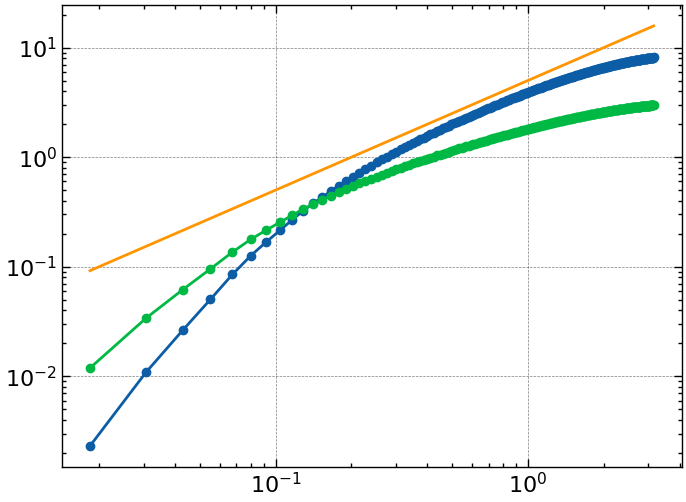

In [12]:
plt.loglog(dx*shells[2:],c[1:], 'o-')
plt.loglog(dx*shells[2:],b[1:], 'o-')

plt.loglog(dx*shells[2:],(5*dx*shells[2:])**(1))

In [13]:
np.savez("Fractal_Struct_func_D2p98", Struct_func = g , norms = norms)    